In [22]:
import matplotlib.pyplot as plt
import numpy as np

# Самостаятельная работа №4

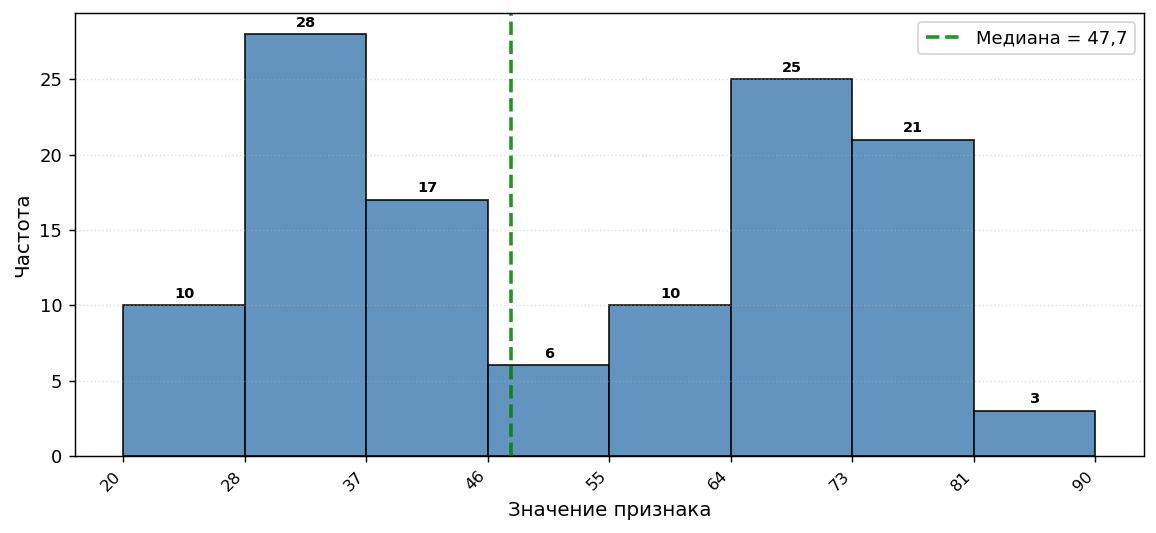

In [23]:
from dataclasses import dataclass

@dataclass
class Section:
    start: float
    end: float
    count: int

In [24]:
data = [
    Section(20, 28, 10),
    Section(28, 37, 28),
    Section(37, 46, 17),
    Section(46, 55, 6),
    Section(55, 64, 10),
    Section(64, 73, 25),
    Section(73, 81, 21),
    Section(81, 90, 3)
]

## Вычисление общего количества наблюдений

In [11]:
total_count = sum(section.count for section in data)
print(f"Общее количество наблюдений: {total_count}")

Общее количество наблюдений: 120


## Вычисление среднего по группированной выборке

In [31]:
weighted_sum = 0
for section in data:
    midpoint = (section.start + section.end) / 2
    weighted_sum += midpoint * section.count

mean = weighted_sum / total_count
print(f"Среднее арифметическое: {mean:.2f}")

Среднее арифметическое: 52.83


## Оценка дисперсии и СКО

In [28]:
weighted_squared_diff = 0
for section in data:
    midpoint = (section.start + section.end) / 2
    weighted_squared_diff += ((midpoint - mean) ** 2) * section.count

variance_biased = weighted_squared_diff / total_count
std_biased = np.sqrt(variance_biased)

variance_unbiased = weighted_squared_diff / (total_count - 1)
std_unbiased = np.sqrt(variance_unbiased)

print(f"Смещенная дисперсия (s²): {variance_biased:.2f}")
print(f"Смещенное СКО (s): {std_biased:.2f}")
print(f"Несмещенная дисперсия (σ²): {variance_unbiased:.2f}")
print(f"Несмещенное СКО (σ): {std_unbiased:.2f}")

Смещенная дисперсия (s²): 367.97
Смещенное СКО (s): 19.18
Несмещенная дисперсия (σ²): 371.07
Несмещенное СКО (σ): 19.26


## Определение количества мод (пиков)

In [32]:
counts = [section.count for section in data]
peaks = []
for i in range(1, len(counts)-1):
    if counts[i] > counts[i-1] and counts[i] > counts[i+1]:
        peaks.append((i, counts[i]))

print(f"Количество мод: {len(peaks)}")
for i, (idx, count) in enumerate(peaks):
    section = data[idx]
    print(f"   Пик {i+1}: интервал {section.start}-{section.end}, частота {count}")

Количество мод: 2
   Пик 1: интервал 28-37, частота 28
   Пик 2: интервал 64-73, частота 25


In [34]:
cumulative = 0
median_interval = None
median_value = None

for i, section in enumerate(data):
    cumulative += section.count
    if cumulative >= total_count / 2:
        median_interval = section
        # Линейная интерполяция внутри интервала
        prev_cumulative = cumulative - section.count
        position = (total_count/2 - prev_cumulative) / section.count
        median_value = section.start + position * (section.end - section.start)
        break

print(f"Оценка симметрии:")
print(f"   Медиана: {median_value:.2f}")
print(f"   Среднее: {mean:.2f}")

Оценка симметрии:
   Медиана: 53.50
   Среднее: 52.83


In [62]:
# Переопределяем переменные для надежности
total = 0
sum_x = 0
sum_x2 = 0

# Сначала вычисляем необходимые статистики
for section in data:
    midpoint = (section.start + section.end) / 2
    count = section.count
    total += count
    sum_x += midpoint * count
    sum_x2 += (midpoint ** 2) * count

# Вычисляем среднее и СКО
mean = sum_x / total
variance = (sum_x2 / total) - (mean ** 2)
std = variance ** 0.5

# Вычисляем коэффициент асимметрии (3-й момент)
weighted_cube_sum = 0
print("Детальный расчет:")

for section in data:
    midpoint = (section.start + section.end) / 2
    count = section.count
    
    # Нормированное отклонение
    z = (midpoint - mean) / std
    
    # Куб нормированного отклонения
    z_cube = z ** 3
    
    # Вклад интервала
    contribution = z_cube * count
    weighted_cube_sum += contribution
    
# Коэффициент асимметрии (Skewness)
skewness = weighted_cube_sum / total

print(f"Сумма z³ × n = {weighted_cube_sum:+.4f}")
print(f"Коэффициент асимметрии (1/n × Σ(z³)) = {skewness:+.6f}")

print(f"Интерпретация коэффициента асимметрии:")
if abs(skewness) < 0.5:
    print(f"  {abs(skewness):.4f} < 0.5 → распределение можно считать СИММЕТРИЧНЫМ")


Детальный расчет:
Сумма z³ × n = +0.0989
Коэффициент асимметрии (1/n × Σ(z³)) = +0.000824
Интерпретация коэффициента асимметрии:
  0.0008 < 0.5 → распределение можно считать СИММЕТРИЧНЫМ


In [42]:
print(f"Сравнение медианы со средним:")
print(f"   Среднее: {mean:.2f}, Медиана: {median_value:.2f}")
if abs(mean - median_value) < std_biased * 0.1:
    conclusion = "подтверждает симметричность распределения"
elif mean > median_value:
    conclusion = "указывает на правостороннюю асимметрию"
else:
    conclusion = "указывает на левостороннюю асимметрию"
print(f"   Вывод: {conclusion}")

Сравнение медианы со средним:
   Среднее: 52.83, Медиана: 53.50
   Вывод: подтверждает симметричность распределения


In [60]:

weighted_quad_sum = 0
print("Детальный расчет 4-го момента:")

for section in data:
    midpoint = (section.start + section.end) / 2
    count = section.count
    
    # Нормированное отклонение
    z = (midpoint - mean) / std
    
    # 4-я степень нормированного отклонения
    z_quad = z ** 4
    
    # Вклад интервала
    contribution = z_quad * count
    weighted_quad_sum += contribution

# "Сырой"
raw_kurtosis= weighted_quad_sum / total

# Эксцесс (с вычитанием 3, чтобы для нормального распределения был 0)
kurtosis = raw_kurtosis - 3

print(f"Эксцесс = {kurtosis:+.6f}")


Детальный расчет 4-го момента:
Эксцесс = -1.517541


In [48]:
cumulative = 0
quartiles = []
for q in [0.25, 0.5, 0.75]:
    cum = 0
    for section in data:
        if cum + section.count >= q * total_count:
            pos = (q * total_count - cum) / section.count
            quartile = section.start + pos * (section.end - section.start)
            quartiles.append(quartile)
            break
        cum += section.count

print(f"Квантиль 25%: {quartiles[0]}")
print(f"Квантиль 50%: {quartiles[1]}")
print(f"Квантиль 75%: {quartiles[2]}")

Квантиль 25%: 34.42857142857143
Квантиль 50%: 53.5
Квантиль 75%: 70.84


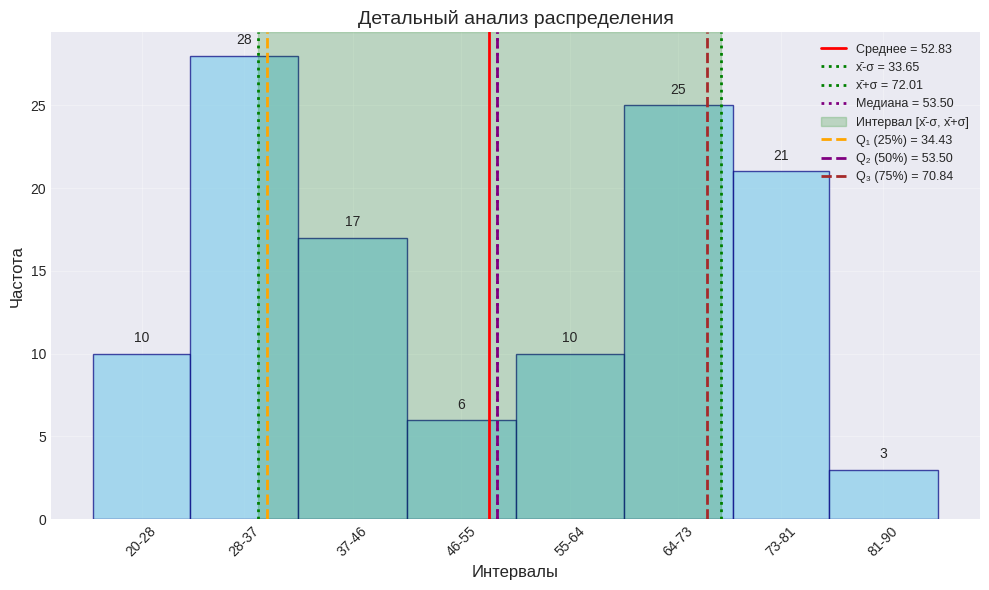

In [67]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

# Подготовка данных
centers = [(elem.start + elem.end) / 2 for elem in data]
widths = [(elem.end - elem.start) for elem in data]
counts = [elem.count for elem in data]
intervals = [f'{elem.start}-{elem.end}' for elem in data]

# Построение графика
bars = ax.bar(centers, counts, widths, color='skyblue', edgecolor='navy', alpha=0.7)


ax.axvline(mean, color='red', linewidth=2, label=f'Среднее = {mean:.2f}')
ax.axvline(mean - std_biased, color='green', linestyle=':', linewidth=2, 
            label=f'x̄-σ = {mean-std_biased:.2f}')
ax.axvline(mean + std_biased, color='green', linestyle=':', linewidth=2,
            label=f'x̄+σ = {mean+std_biased:.2f}')
ax.axvline(median_value, color='purple', linestyle=':', linewidth=2, 
            label=f'Медиана = {median_value:.2f}')

# Добавление интервала [x̄-σ, x̄+σ]
ax.axvspan(mean - std_biased, mean + std_biased, alpha=0.2, color='green', 
            label=f'Интервал [x̄-σ, x̄+σ]')


# Добавление квантилей
ax.axvline(quartiles[0], color='orange', linestyle='--', linewidth=2, 
            label=f'Q₁ (25%) = {quartiles[0]:.2f}')
ax.axvline(quartiles[1], color='purple', linestyle='--', linewidth=2, 
            label=f'Q₂ (50%) = {quartiles[1]:.2f}')
ax.axvline(quartiles[2], color='brown', linestyle='--', linewidth=2, 
            label=f'Q₃ (75%) = {quartiles[2]:.2f}')

# Добавление подписей
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
            str(count), ha='center', va='bottom', fontsize=10)

# Настройка подписей
ax.set_xlabel('Интервалы', fontsize=12)
ax.set_ylabel('Частота', fontsize=12)
ax.set_title('Распределение частот по интервалам', fontsize=14)
ax.set_xticks(centers)
ax.set_xticklabels(intervals, rotation=45)
ax.grid(axis='y', alpha=0.3)

ax.set_xlabel('Интервалы', fontsize=12)
ax.set_ylabel('Частота', fontsize=12)
ax.set_title('Детальный анализ распределения', fontsize=14)
ax.set_xticks(centers)
ax.set_xticklabels(intervals, rotation=45)
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

В качестве меры центра лучше выбрать медиану т.к. наблюдвется бимодальность

Общее количество наблюдений: 120

1.1 Среднее арифметическое (по группированным данным): 53.02

1.2 Оценки дисперсии и СКО:
   Смещенная дисперсия (s²): 361.65
   Смещенное СКО (s): 19.02
   Несмещенная дисперсия (σ²): 364.69
   Несмещенное СКО (σ): 19.10

2.1 Количество мод (пиков): 2
   Пик 1: интервал 29-37, частота 28
   Пик 2: интервал 64-73, частота 25

2.2 Оценка симметрии:
   Медиана: 53.50
   Среднее: 53.02
   Распределение: симметричное (разница: -0.48)

2.3 Сравнение медианы со средним:
   Среднее: 53.02, Медиана: 53.50
   Вывод: подтверждает симметричность распределения

2.4 Признаки бимодальности или выбросов:
   ✓ Наблюдается бимодальность (2 пика)
   ✗ Выбросы не обнаружены

2.5 Рекомендуемая мера центра:
   Для бимодального распределения лучше использовать:
   - Две моды для описания каждого пика
   - Медиану как робастную меру
   Среднее арифметическое может быть неинформативным

2.6 Предположения о законе распределения:
   Форма: 2 пика, симметричное
   Предполагаемый

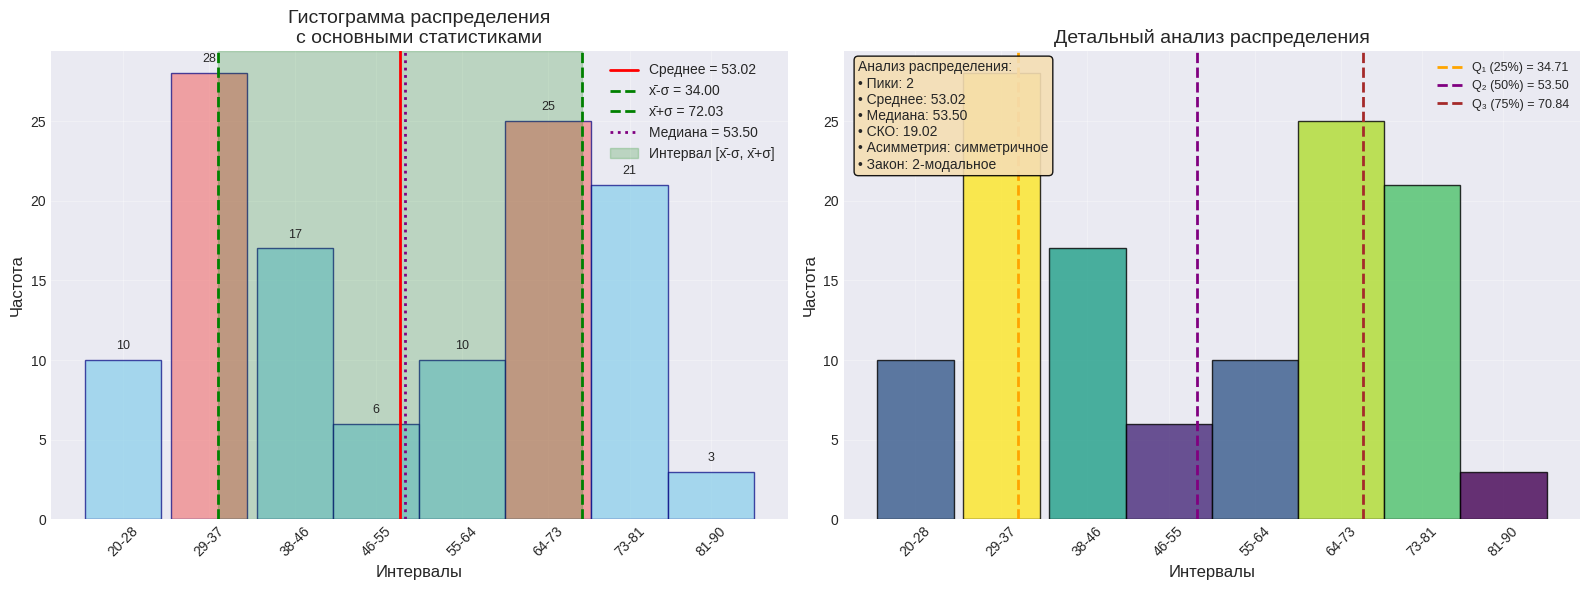


ИТОГОВЫЙ ОТЧЕТ ПО АНАЛИЗУ ГИСТОГРАММЫ

1. ОСНОВНЫЕ СТАТИСТИКИ:
   • Объем выборки: n = 120
   • Среднее: x̄ = 53.02
   • Медиана: Me = 53.50
   • Дисперсия (смещ.): s² = 361.65
   • СКО: s = 19.02
   • Квартили: Q₁ = 34.71, Q₂ = 53.50, Q₃ = 70.84

2. ФОРМА РАСПРЕДЕЛЕНИЯ:
   • Количество мод: 2
   • Симметрия: симметричное
   • Соотношение среднего и медианы: подтверждает симметричность распределения

3. ВЫВОДЫ:
   • Распределение является бимодальным
   • Выбросы не обнаружены
   • Рекомендуемая мера центра: медиана
   • Предполагаемый закон: БИМОДАЛЬНОЕ распределение


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from dataclasses import dataclass
from scipy import stats

@dataclass
class Section:
    start: float
    end: float
    count: int

data = [
    Section(20, 28, 10),
    Section(29, 37, 28),
    Section(38, 46, 17),
    Section(46, 55, 6),
    Section(55, 64, 10),
    Section(64, 73, 25),
    Section(73, 81, 21),
    Section(81, 90, 3)
]

# 


# ============= 1.1  =============


# ============= 1.2 Оценка дисперсии и СКО =============
# Смещенная дисперсия (деление на n)

# Несмещенная дисперсия (деление на n-1)


# ============= 2.1  =============
# Находим локальные максимумы в частотах


# ============= 2.2 Оценка симметрии распределения =============
# Вычисляем медиану для оценки симметрии


# ============= 2.3 Сравнение медианы со средним =============


# ============= 2.4 Признаки бимодальности или выбросов =============


# ============= 2.5 Выбор меры центра =============
print(f"\n2.5 Рекомендуемая мера центра:")
if len(peaks) >= 2:
    print("   Для бимодального распределения лучше использовать:")
    print("   - Две моды для описания каждого пика")
    print("   - Медиану как робастную меру")
    print("   Среднее арифметическое может быть неинформативным")
elif abs(mean - median_value) > std_biased * 0.2:
    print("   Для асимметричного распределения рекомендуется использовать МЕДИАНУ")
    print("   как более устойчивую к асимметрии меру")
else:
    print("   Для симметричного распределения можно использовать СРЕДНЕЕ")
    print("   как наиболее информативную меру")

# ============= 2.6 Предположения о законе распределения =============
print(f"\n2.6 Предположения о законе распределения:")

# Анализ формы распределения
print(f"   Форма: {len(peaks)} пика, {symmetry}")

if len(peaks) >= 2:
    print("   Предполагаемый закон: БИМОДАЛЬНОЕ распределение")
    print("   Признаки: наличие двух явных пиков")
elif counts[0] > counts[1] * 1.5 and all(counts[i] <= counts[i-1] for i in range(1, len(counts))):
    print("   Предполагаемый закон: ЭКСПОНЕНЦИАЛЬНОЕ распределение")
    print("   Признаки: резкий спад частот от начала к концу")
elif abs(mean - median_value) < std_biased * 0.1 and len(peaks) == 1:
    print("   Предполагаемый закон: НОРМАЛЬНОЕ распределение")
    print("   Признаки: симметричность, один пик")
else:
    print("   Предполагаемый закон: Смешанное или другое распределение")
    print("   Требуется дополнительный анализ")

# ============= Визуализация с расчетными параметрами =============
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Гистограмма 1: с основными статистиками
ax1 = axes[0]
centers = [(section.start + section.end) / 2 for section in data]
widths = [section.end - section.start for section in data]
counts = [section.count for section in data]
intervals = [f'{int(section.start)}-{int(section.end)}' for section in data]

# Цветовая карта для пиков
colors = ['lightcoral' if i in [p[0] for p in peaks] else 'skyblue' for i in range(len(data))]
bars = ax1.bar(centers, counts, widths, color=colors, alpha=0.7, edgecolor='navy', linewidth=1)

# Отметка среднего и интервала [x̄-σ, x̄+σ]

# Подписи
ax1.set_xlabel('Интервалы', fontsize=12)
ax1.set_ylabel('Частота', fontsize=12)
ax1.set_title('Гистограмма распределения\nс основными статистиками', fontsize=14)
ax1.set_xticks(centers)
ax1.set_xticklabels(intervals, rotation=45)
ax1.legend(loc='upper right', fontsize=10)
ax1.grid(True, alpha=0.3)

# Добавление подписей частот
for bar, count in zip(bars, counts):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, height + 0.5, 
            str(count), ha='center', va='bottom', fontsize=9)

# Гистограмма 2: с детальным анализом
ax2 = axes[1]

# Подготовка данных для квантилей
# Вычисление квартилей (приближенно)


# Построение столбцов с градиентом
norm = plt.Normalize(min(counts), max(counts))
colors2 = plt.cm.viridis(norm(counts))

bars2 = ax2.bar(centers, counts, widths, color=colors2, alpha=0.8, edgecolor='black', linewidth=1)

# Отметка квантилей


# Добавление текста с анализом
analysis_text = f"""Анализ распределения:
• Пики: {len(peaks)}
• Среднее: {mean:.2f}
• Медиана: {median_value:.2f}
• СКО: {std_biased:.2f}
• Асимметрия: {symmetry}
• Закон: {len(peaks)}-модальное"""

ax2.text(0.02, 0.98, analysis_text, transform=ax2.transAxes, 
         fontsize=10, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.9))

ax2.set_xlabel('Интервалы', fontsize=12)
ax2.set_ylabel('Частота', fontsize=12)
ax2.set_title('Детальный анализ распределения', fontsize=14)
ax2.set_xticks(centers)
ax2.set_xticklabels(intervals, rotation=45)
ax2.legend(loc='upper right', fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============= Вывод результатов в структурированном виде =============
print("\n" + "="*60)
print("ИТОГОВЫЙ ОТЧЕТ ПО АНАЛИЗУ ГИСТОГРАММЫ")
print("="*60)

print(f"\n1. ОСНОВНЫЕ СТАТИСТИКИ:")
print(f"   • Объем выборки: n = {total_count}")
print(f"   • Среднее: x̄ = {mean:.2f}")
print(f"   • Медиана: Me = {median_value:.2f}")
print(f"   • Дисперсия (смещ.): s² = {variance_biased:.2f}")
print(f"   • СКО: s = {std_biased:.2f}")
print(f"   • Квартили: Q₁ = {quartiles[0]:.2f}, Q₂ = {quartiles[1]:.2f}, Q₃ = {quartiles[2]:.2f}")

print(f"\n2. ФОРМА РАСПРЕДЕЛЕНИЯ:")
print(f"   • Количество мод: {len(peaks)}")
print(f"   • Симметрия: {symmetry}")
print(f"   • Соотношение среднего и медианы: {conclusion}")

print(f"\n3. ВЫВОДЫ:")
print(f"   • Распределение {'является' if len(peaks)>=2 else 'не является'} бимодальным")
if outliers:
    print(f"   • Обнаружены выбросы в интервалах: {', '.join([f'{s.start}-{s.end}' for _, s in outliers])}")
else:
    print(f"   • Выбросы не обнаружены")
print(f"   • Рекомендуемая мера центра: {'медиана' if abs(mean-median_value)>std_biased*0.2 or len(peaks)>=2 else 'среднее'}")
print(f"   • Предполагаемый закон: {'БИМОДАЛЬНОЕ' if len(peaks)>=2 else 'НОРМАЛЬНОЕ' if abs(mean-median_value)<std_biased*0.1 else 'АСИММЕТРИЧНОЕ'} распределение")